In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from scipy.signal import sawtooth, square
from IPython.display import Audio, HTML

%config InlineBackend.figure_formats = ['svg']

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.RenderedHTMLCommon{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")




Wavetable synthesis extends the principle of [table-lookup oscillators](https://ringbuffer.org/sound_synthesis_introduction/Processed_Recording/table_lookup_oscillators/). 
The approach became popular in the early 80s because it allowed the creation new, complex sounds.
Early hardware instruments relied on a digital waveform generation, paired with analog filters and amplifiers.
The novelty were arbitrary waveforms that resulted in timbres that were impossible to achieve with previous technologies.
Although the approch was *revolutionary*, these early wavetable instruments could not compete with other devices of the early 80s (like the DX7).


# Notable Instruments

**PPG Wave:**

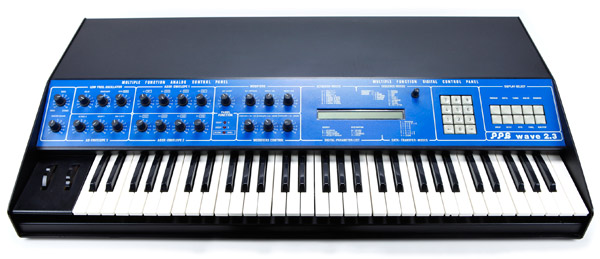



- **PPG Wave**
    - 1981 (Palm Products, Germany)
    - 8-voice polyphony
    - analog VCA & VCF
    - \$7,000-10,000
- **Waldorf Microwave**
    - 1989 (Waldorf, Germany)
    - 8-voice polyphony
    - analog VCA & VCF
    - \$5,000
- **Massive**
    - 2006 (Native Instruments, Germany)
    - sofwtare synth with 64 voices
- **Serum**
    - 2015 (Xfer Records, USA)
- **Argon8**
    - eight-voice polyphonic
    - 2020 (Modal Electronics, UK)

-----

## Well Known Examples

In [2]:
print("PPG Wave I (1983):")

HTML('<iframe width="560" height="315" src="https://www.youtube.com/embed/OlaTeXX3uH8?si=hGlvdrbLkUDB6MJE" frameborder="0" allowfullscreen></iframe>')

PPG Wave I (1983):


In [3]:
print("PPG Wave II (1985):")

HTML('<iframe width="560" height="315" src="https://www.youtube.com/embed/ldAp-mZqAro?si=3NEqU_fPZAtj-PTb" frameborder="0" allowfullscreen></iframe>')

PPG Wave II (1985):


In [4]:
print("Massive (2010):")

HTML('<iframe width="560" height="315" src="https://www.youtube.com/embed/WSeNSzJ2-Jw?si=XUHEVZS4uRjyPPeJ" frameborder="0" allowfullscreen></iframe>')

Massive (2010):


-----

# Synthesis Principle by Example

Wavetable synthesis extends the table lookup oscillator principle with a simple feature: 

- **Interpolation between different waveforms (tables).**
  

---

## 1: Define the Wavetable

A wavetable is a collection of waveforms that can be stored in different data formats, such as arrays/matrices or dictionaries. The following example uses a simple wavetable with three waveforms:

- Sine wave
- Square wave
- Sawtooth

Each of the waveforms has the length $N=4096$, 
resutling in a matrix $\mathrm{WT}_{M,N}$ with $M=3$ different waveforms:


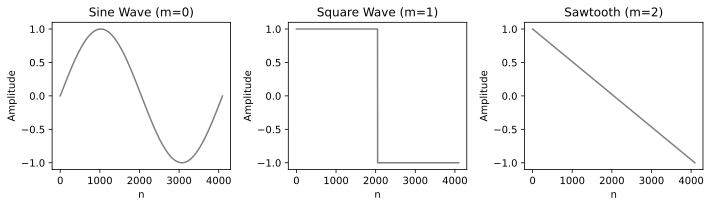

In [5]:
def create_wavetable(table_size=pow(2,12)):
    
    x = np.linspace(0, 1, table_size, endpoint=False)
 
    wavetable = np.zeros([table_size,3])

    wavetable[:,0] = np.sin(2 * np.pi * x)
    wavetable[:,1] = square(2 * np.pi * x)
    wavetable[:,2] = sawtooth(2 * np.pi * x, width=0)
    
    return wavetable

wavetable = create_wavetable()

# Visualize the waveforms
plt.figure(figsize=(10, 3))

plt.subplot(1, 3, 1)
plt.plot(wavetable[:,0],color='gray')
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.title('Sine Wave (m=0)')

plt.subplot(1, 3, 2)
plt.plot(wavetable[:,1],color='gray')
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.title('Square Wave (m=1)')

plt.subplot(1, 3, 3)
plt.plot(wavetable[:,2],color='gray')
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.title('Sawtooth (m=2)')


plt.tight_layout()
plt.show()

-----

## 2: Waveform Interpolation

With the matrix representation of the wavetable, the index $m$ can be used to blend between neighboring waveforms, using linear interpolation. 

---

### Example A: LFO

The following plots and audio example show a LFO modulation through all three waveforms:

In [6]:
def wavetable_synth(waveform, frequency, wavetable, sample_rate):
    
    table_length = np.size(wavetable,0)
    
    output = np.zeros_like(waveform)
    phase  = 0
    
    for i in range(len(waveform)):
        
        index = int((phase) / (2*np.pi) * table_length)

        w     = waveform[i]
        
        lower = int(np.floor(w))
        upper = int(np.ceil(w))
        frac  = upper-w
        
        
        val = (frac) * wavetable[index,lower] +  (1-frac) * wavetable[index,upper]
        
        output[i] = val

        phase = (phase + frequency / sample_rate * np.pi) % (2*np.pi)
        
    return output

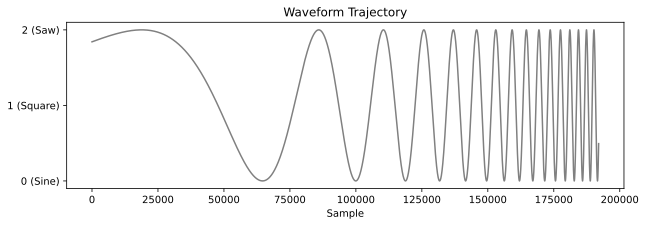

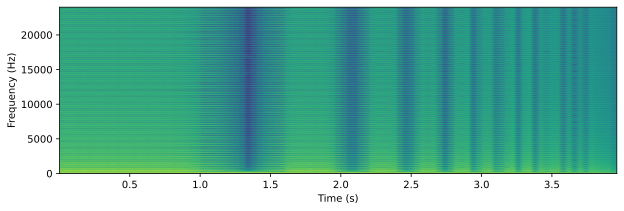

In [7]:
# Generate a sine wave at 440 Hz for 2 seconds
frequency   = 320
duration    = 4
sample_rate = 48000

t                   = np.linspace(0,duration,sample_rate*duration)
#waveform_trajectory = 2*np.logspace(0,-8,duration*sample_rate)
#waveform_trajectory = 2*pow(np.sin(np.linspace(0,12,duration*sample_rate)), 8)
waveform_trajectory = 1+np.sin(np.logspace(0,2, duration*sample_rate))
amp_trajectory = pow(np.linspace(1,0,duration*sample_rate),0.8)

synth_audio = wavetable_synth(waveform_trajectory, frequency, wavetable, sample_rate)

synth_audio *= amp_trajectory

plt.figure(figsize=(10, 3))
plt.plot(waveform_trajectory, color='gray')
plt.xlabel('Sample')
plt.yticks([0,1,2],labels=['0 (Sine)','1 (Square)','2 (Saw)'])
plt.title('Waveform Trajectory')

plt.figure(figsize=(10, 3))
Pxx, freqs, bins, im = plt.specgram(synth_audio, NFFT=2048, Fs=48000)
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
 



# Play the generated sound
Audio(synth_audio, rate=sample_rate)

---

### Example B: Exponential Attack

The following plots and audio example show a modulation with an exponential envelope, resulting in an attack transient:

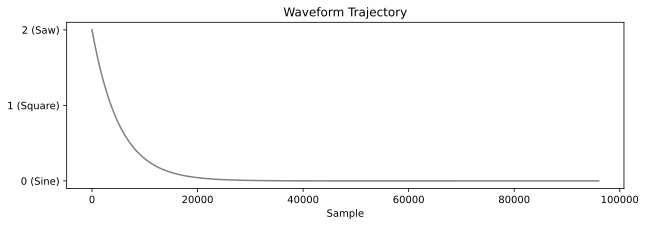

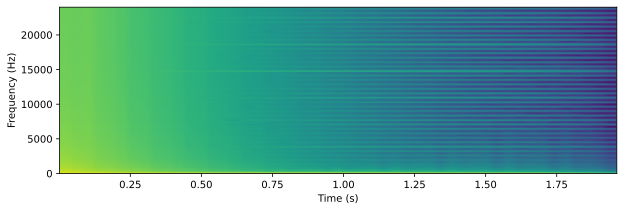

In [8]:

# Generate a sine wave at 440 Hz for 2 seconds
frequency   = 110
duration    = 2
sample_rate = 48000

waveform_trajectory = 2*np.logspace(0,-8,duration*sample_rate)
#waveform_trajectory = 2*np.sin(np.linspace(0,3,duration*sample_rate))
amp_trajectory = pow(np.linspace(1,0,duration*sample_rate),2)

synth_audio = wavetable_synth(waveform_trajectory, frequency, wavetable, sample_rate)

synth_audio *= amp_trajectory


plt.figure(figsize=(10, 3))
plt.plot(waveform_trajectory, color='gray')
plt.xlabel('Sample')
plt.yticks([0,1,2],labels=['0 (Sine)','1 (Square)','2 (Saw)'])
plt.title('Waveform Trajectory')

plt.figure(figsize=(10, 3))
Pxx, freqs, bins, im = plt.specgram(synth_audio, NFFT=2048, Fs=48000)
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')


# Play the generated sound
Audio(synth_audio, rate=sample_rate)